# Carreau-Yasuda (CY) Parameter Extraction

This notebook fits the **Carreau-Yasuda rheological model** to each unique slurry formulation in the expanded dataset.

The five CY parameters extracted per formulation — $\eta_0$, $\eta_\infty$, $\lambda$, $n$, $a$ — encode the full shear-thinning behaviour of the slurry as physically interpretable features that can then be used as inputs to machine learning models.

| Parameter | Symbol | Physical meaning |
|---|---|---|
| Zero-shear viscosity | $\eta_0$ | Viscosity plateau at rest — controls particle settling |
| Infinite-shear viscosity | $\eta_\infty$ | Viscosity under extreme mixing — controls coating thickness |
| Relaxation time | $\lambda$ | Inverse of the critical shear rate at transition |
| Power-law index | $n$ | Degree of shear thinning ($n < 1$ for slurries) |
| Yasuda parameter | $a$ | Width of the shear-thinning transition region |

In [26]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import warnings

# Suppress convergence warnings from the non-linear optimizer
warnings.filterwarnings("ignore")

## 2. Load Data

In [27]:
df = pd.read_csv('../data/processed/combined_slurry_data_expanded.csv')

print(f"Rows: {len(df)}  |  Unique formulations (Composite_Mix_ID): {df['Composite_Mix_ID'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Rows: 178  |  Unique formulations (Composite_Mix_ID): 68
Columns: ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s', 'Source_Batch', 'Composite_Mix_ID', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct']


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,Viscosity_at_shear_rate_1_1/s,Viscosity_at_shear_rate_10_1/s,Viscosity_at_shear_rate_100_1/s,Source_Batch,Composite_Mix_ID,NMC_pct,C65_pct,KS6L_pct,PVDF_pct
0,Hypermer,73.0,0.50,10.56640,3.78921,1.99755,Batch_1,F1_Hypermer_73.0_0.5,96.0,2.0,0.0,2.0
1,Hypermer,73.0,0.25,71.65190,14.08460,4.82515,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
2,Hypermer,73.0,0.25,9.64639,3.26827,1.61720,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
3,Hypermer,77.0,0.25,61.11070,18.77450,7.51220,Batch_1,F1_Hypermer_77.0_0.25,96.0,2.0,0.0,2.0
4,Hypermer,73.0,0.25,8.37111,4.83186,2.30422,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0


## 3. Define the Carreau-Yasuda Equation

The CY model describes the full shear-thinning flow curve:

$$\eta(\dot\gamma) = \eta_\infty + (\eta_0 - \eta_\infty)\left[1 + (\lambda\,\dot\gamma)^a\right]^{\frac{n-1}{a}}$$

`curve_fit` will find the five parameters $(\eta_0, \eta_\infty, \lambda, n, a)$ that minimise the residuals between this equation and the measured viscosities at 1, 10, and 100 1/s.

In [28]:
def carreau_yasuda(shear_rate, eta_0, eta_inf, lambda_time, n, a):
    """
    Carreau-Yasuda viscosity model.

    Parameters
    ----------
    shear_rate   : array-like  — applied shear rate (1/s)
    eta_0        : float       — zero-shear viscosity (Pa·s)
    eta_inf      : float       — infinite-shear viscosity (Pa·s)
    lambda_time  : float       — relaxation time (s); inverse of critical shear rate
    n            : float       — power-law index (< 1 = shear thinning)
    a            : float       — Yasuda parameter (transition width)
    """
    return eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * shear_rate)**a)**((n - 1) / a)

## 4. Column Definitions

Declare which columns to treat as viscosity targets and which input features to carry forward into the ML dataset.

In [29]:
shear_rates = np.array([1.0, 10.0, 100.0])

target_cols = [
    'Viscosity_at_shear_rate_1_1/s',
    'Viscosity_at_shear_rate_10_1/s',
    'Viscosity_at_shear_rate_100_1/s',
]

# Input features to carry into the final ML-ready physics dataset
input_cols = [
    'Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct',
    'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch',
]

print("Target columns:", target_cols)
print("Input columns: ", input_cols)

Target columns: ['Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s']
Input columns:  ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch']


## 5. Fit CY Parameters per Formulation

For each unique `Composite_Mix_ID`, all replicates at all three shear rates are pooled together and passed to `scipy.optimize.curve_fit`.  
Physical bounds are imposed on the optimizer to prevent it returning thermodynamically impossible parameter values.

In [17]:
cy_dataset = []
failed_fits = []

print(f"Fitting CY parameters for {df['Composite_Mix_ID'].nunique()} unique formulations...\n")

for mix_id, group_df in df.groupby('Composite_Mix_ID'):

    # Pool all replicates: tile shear rates to match the flattened viscosity array
    x_data = np.tile(shear_rates, len(group_df))
    y_data = group_df[target_cols].values.flatten()

    # Initial guess: [eta_0, eta_inf, lambda_time, n, a]
    initial_guess = [np.max(y_data), np.min(y_data), 1.0, 0.5, 2.0]

    # Physical bounds — prevents the optimizer returning impossible values
    bounds = (
        [0.1,   0.01,  0.001, 0.1, 0.1],               # lower
        [np.inf, np.max(y_data) + 50, 100.0, 1.0, 10.0] # upper
    )

    try:
        popt, _ = curve_fit(
            carreau_yasuda, x_data, y_data,
            p0=initial_guess, bounds=bounds, maxfev=15000
        )

        record = group_df[input_cols].iloc[0].to_dict()
        record['Composite_Mix_ID'] = mix_id
        record['eta_0']        = popt[0]   # zero-shear viscosity
        record['eta_inf']      = popt[1]   # infinite-shear viscosity
        record['lambda_time']  = popt[2]   # relaxation time
        record['n']            = popt[3]   # power-law index
        record['a']            = popt[4]   # Yasuda transition width

        # Goodness-of-fit: RMSE between CY curve and measured viscosities
        y_pred = carreau_yasuda(x_data, *popt)
        record['CY_Fit_RMSE'] = np.sqrt(np.mean((y_data - y_pred) ** 2))

        cy_dataset.append(record)

    except RuntimeError:
        failed_fits.append(mix_id)

print(f"Successful fits : {len(cy_dataset)}")
print(f"Failed fits     : {len(failed_fits)}" + (f"  -> {failed_fits}" if failed_fits else ""))

Fitting CY parameters for 68 unique formulations...

Successful fits : 68
Failed fits     : 0


## 6. Build the Physics-Informed ML Dataset

Assemble the extracted CY parameters alongside the original input features into a single dataframe, ready for machine learning.

In [18]:
physics_df = pd.DataFrame(cy_dataset)

print(f"Dataset shape: {physics_df.shape}")
print(f"\nCY parameter summary:")
display(physics_df[['eta_0', 'eta_inf', 'lambda_time', 'n', 'a', 'CY_Fit_RMSE']].describe().round(4))

display(physics_df.head())

Dataset shape: (68, 15)

CY parameter summary:


,eta_0,eta_inf,lambda_time,n,a,CY_Fit_RMSE
count,68.0000,68.0000,68.0000,68.0000,68.0000,68.0000
mean,89.5668,2.3647,2.0096,0.3683,3.8326,7.9274
std,121.6148,1.4499,1.5856,0.1635,2.7484,11.8461
min,1.2059,0.0100,0.2382,0.1000,0.5342,0.0000
25%,10.3206,1.2377,0.8546,0.2583,1.8940,0.2556
50%,41.9027,2.1157,1.7550,0.3575,3.0597,1.6850
75%,117.6690,3.2604,2.5676,0.4763,4.4053,11.6061
max,686.2466,5.4093,7.7429,0.6697,10.0000,45.1596


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,NMC_pct,C65_pct,KS6L_pct,PVDF_pct,Source_Batch,Composite_Mix_ID,eta_0,eta_inf,lambda_time,n,a,CY_Fit_RMSE
0,Tego,77.0,0.00,NaN,NaN,NaN,NaN,Batch_2,B_Tego_77.0_0.0,171.088699,3.728496,0.990848,0.334162,1.822931,6.815673e-09
1,Hypermer,69.0,0.00,96.0,2.0,0.0,2.0,Batch_2,F1_Hypermer_69.0_0.0,4.766136,0.762944,0.238239,0.600391,0.534214,9.062299e-02
2,Hypermer,69.0,0.25,96.0,2.0,0.0,2.0,Batch_1,F1_Hypermer_69.0_0.25,8.803211,0.782426,2.055173,0.581302,1.447563,1.724233e+00
3,Hypermer,69.0,0.50,96.0,2.0,0.0,2.0,Batch_1,F1_Hypermer_69.0_0.5,6.493486,0.774289,2.035295,0.481390,2.202961,9.229776e-01
4,Hypermer,72.0,0.00,96.0,2.0,0.0,2.0,Batch_2,F1_Hypermer_72.0_0.0,43.694271,2.535353,2.613443,0.378424,2.953831,8.894141e+00


## 7. Visualise Fitted CY Curves

Plot the fitted Carreau-Yasuda curve against the raw measured viscosity points for a random sample of formulations. Each dot is a single replicate measurement; the line is what the optimizer converged on.

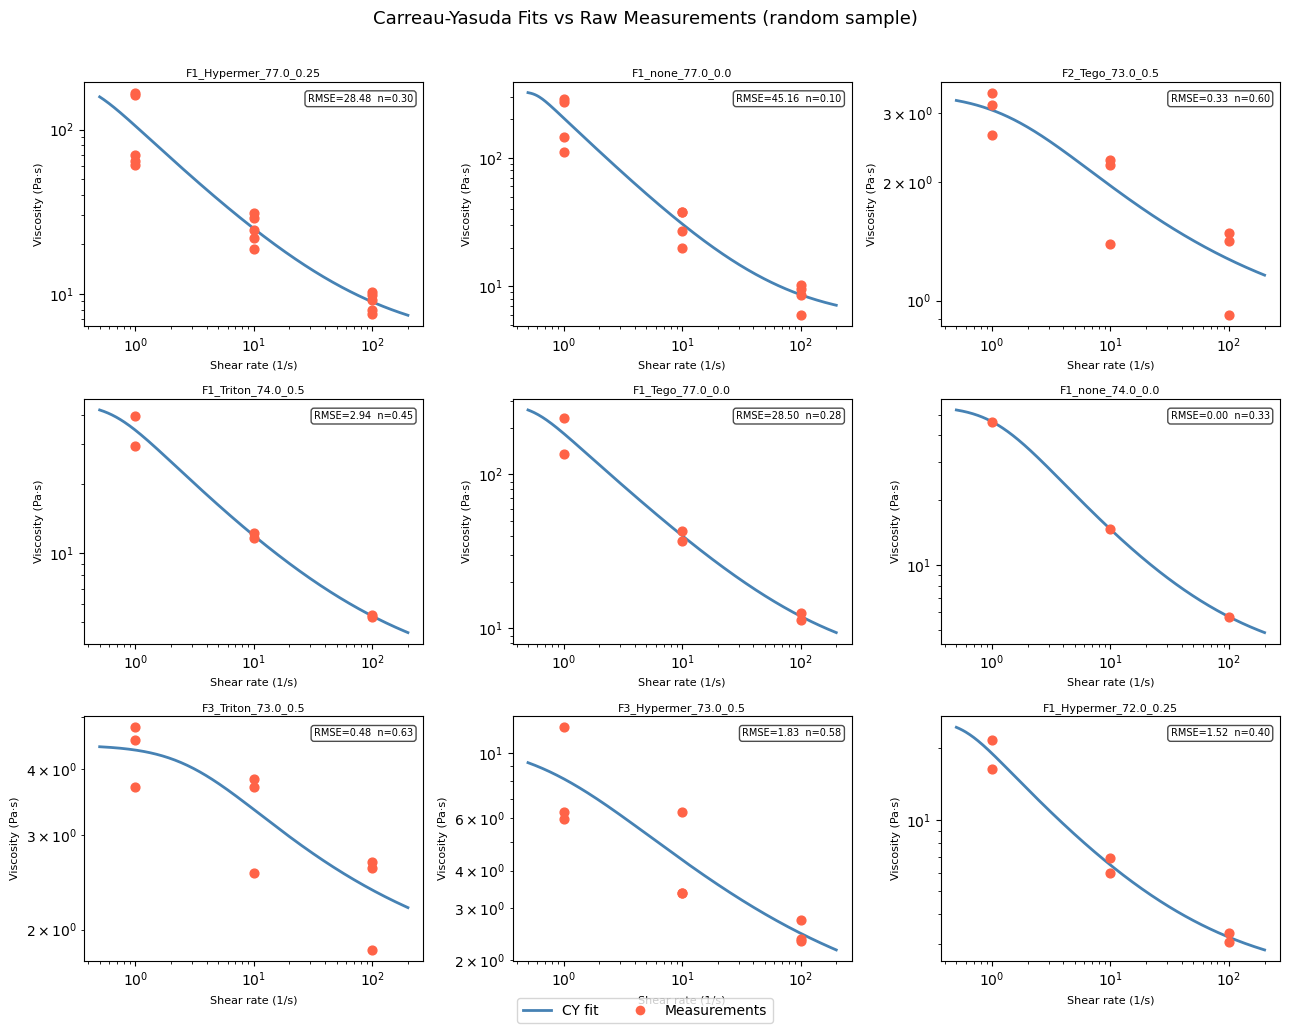

In [19]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
sample_ids = rng.choice(physics_df['Composite_Mix_ID'].values, size=9, replace=False)

# Dense shear-rate axis for smooth CY curves
gamma_plot = np.logspace(np.log10(0.5), np.log10(200), 300)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for ax, mix_id in zip(axes, sample_ids):
    row = physics_df[physics_df['Composite_Mix_ID'] == mix_id].iloc[0]

    # Fitted CY curve
    eta_fit = carreau_yasuda(gamma_plot, row['eta_0'], row['eta_inf'],
                             row['lambda_time'], row['n'], row['a'])
    ax.plot(gamma_plot, eta_fit, color='steelblue', linewidth=2, label='CY fit')

    # Raw replicate measurements using target_cols
    raw = df[df['Composite_Mix_ID'] == mix_id]
    for _, rep in raw.iterrows():
        ax.scatter(shear_rates, rep[target_cols].values,
                   color='tomato', s=40, zorder=5)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(mix_id, fontsize=8, pad=4)
    ax.set_xlabel('Shear rate (1/s)', fontsize=8)
    ax.set_ylabel('Viscosity (Pa·s)', fontsize=8)
    ax.text(0.97, 0.95,
            f"RMSE={row['CY_Fit_RMSE']:.2f}  n={row['n']:.2f}",
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

# Shared legend
fig.legend(handles=[
    plt.Line2D([0], [0], color='steelblue', linewidth=2, label='CY fit'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
               markersize=8, label='Measurements'),
], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Carreau-Yasuda Fits vs Raw Measurements (random sample)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

# 1. Define Features (X) and Targets (y) from physics_df
X_raw = physics_df[['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct',
                     'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct']]
X = pd.get_dummies(X_raw, drop_first=True)

# Missing composition percentages mean the component was absent (0%) — fill accordingly
X = X.fillna(0.0)

print(f"Feature matrix shape: {X.shape}  |  NaN count: {X.isna().sum().sum()}")

cy_targets = ['eta_0', 'eta_inf', 'lambda_time', 'n', 'a']
y = physics_df[cy_targets]

# 2. Gaussian Process kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

# 3. 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {target: {'R2': [], 'RMSE': []} for target in cy_targets}

print("\nTraining Gaussian Process Regressor on Carreau-Yasuda Parameters...\n")

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scale features — fit on train, apply to both
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    # Scale targets — crucial for GPR convergence across parameters of different magnitudes
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)

    gpr.fit(X_train_scaled, y_train_scaled)

    y_pred_scaled, _ = gpr.predict(X_test_scaled, return_std=True)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    for i, target in enumerate(cy_targets):
        results[target]['R2'].append(r2_score(y_test.iloc[:, i], y_pred[:, i]))
        results[target]['RMSE'].append(np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i])))

    print(f"  Fold {fold} done")

# 4. Summary
print("\n=== GPR Physics Prediction Accuracy (5-Fold CV) ===")
for target in cy_targets:
    mean_r2  = np.mean(results[target]['R2'])
    std_r2   = np.std(results[target]['R2'])
    mean_rmse = np.mean(results[target]['RMSE'])
    print(f"{target:12s}  R2: {mean_r2:.4f} ± {std_r2:.4f}   RMSE: {mean_rmse:.4f}")

Feature matrix shape: (68, 9)  |  NaN count: 0

Training Gaussian Process Regressor on Carreau-Yasuda Parameters...

  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done

=== GPR Physics Prediction Accuracy (5-Fold CV) ===
eta_0         R2: 0.0491 ± 0.2370   RMSE: 112.3984
eta_inf       R2: 0.0344 ± 0.3722   RMSE: 1.3249
lambda_time   R2: -0.0780 ± 0.0737   RMSE: 1.5400
n             R2: -0.0353 ± 0.1466   RMSE: 0.1598
a             R2: -0.0633 ± 0.1406   RMSE: 2.7224


## 8. Ablation Studies for CY + GPR

This section implements a controlled ablation to test which modelling changes improve prediction of CY parameters.

Ablations included:
1. **A:** Fixed-$a$ CY fit (linear-space residuals) + standard GPR  
2. **B:** Fixed-$a$ CY fit (log-space residuals) + standard GPR  
3. **C:** Fixed-$a$ CY fit (log-space residuals) + weighted, ARD GPR

We keep data splits constant (`random_state=42`) so differences are attributable to modelling choices.

In [31]:
from scipy.optimize import least_squares


def cy_fixed_a(shear_rate, eta_0, eta_inf, lambda_time, n, a_fixed=2.0):
    """Carreau-Yasuda model with fixed a for improved identifiability."""
    return eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * shear_rate) ** a_fixed) ** ((n - 1) / a_fixed)


def fit_cy_variant(group_df, shear_rates, target_cols, variant="fixed_a_linear", a_fixed=2.0):
    """
    Fit constrained CY parameters for one formulation.

    Variants
    --------
    fixed_a_linear : fit in linear viscosity space
    fixed_a_log    : fit in log-viscosity space
    """
    x_data = np.tile(shear_rates, len(group_df))
    y_data = group_df[target_cols].values.flatten().astype(float)

    # Parameters optimized: [eta_0, eta_inf, lambda_time, n]
    theta0 = np.array([np.max(y_data), np.min(y_data), 1.0, 0.5], dtype=float)
    lower = np.array([0.1, 0.01, 0.001, 0.1], dtype=float)
    upper = np.array([np.inf, np.max(y_data) + 50.0, 100.0, 1.0], dtype=float)

    if variant == "fixed_a_linear":
        def residuals(theta):
            y_hat = cy_fixed_a(x_data, theta[0], theta[1], theta[2], theta[3], a_fixed=a_fixed)
            return y_data - y_hat
    elif variant == "fixed_a_log":
        eps = 1e-6

        def residuals(theta):
            y_hat = cy_fixed_a(x_data, theta[0], theta[1], theta[2], theta[3], a_fixed=a_fixed)
            return np.log(y_data + eps) - np.log(y_hat + eps)
    else:
        raise ValueError(f"Unknown variant: {variant}")

    fit = least_squares(residuals, x0=theta0, bounds=(lower, upper), max_nfev=20000)
    eta_0, eta_inf, lambda_time, n = fit.x

    y_pred = cy_fixed_a(x_data, eta_0, eta_inf, lambda_time, n, a_fixed=a_fixed)
    rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))

    return {
        "eta_0": eta_0,
        "eta_inf": eta_inf,
        "lambda_time": lambda_time,
        "n": n,
        "a": a_fixed,
        "CY_Fit_RMSE": rmse,
    }


def build_physics_df_variant(df, input_cols, target_cols, shear_rates, variant, a_fixed=2.0):
    """Build a physics-informed dataset using a selected CY fit variant."""
    records = []
    failed = []

    for mix_id, group_df in df.groupby("Composite_Mix_ID"):
        try:
            record = group_df[input_cols].iloc[0].to_dict()
            record["Composite_Mix_ID"] = mix_id
            record.update(
                fit_cy_variant(
                    group_df,
                    shear_rates=shear_rates,
                    target_cols=target_cols,
                    variant=variant,
                    a_fixed=a_fixed,
                )
            )
            records.append(record)
        except Exception:
            failed.append(mix_id)

    physics_df_variant = pd.DataFrame(records)
    print(f"{variant}: successful={len(physics_df_variant)} | failed={len(failed)}")
    return physics_df_variant, failed

In [32]:
def evaluate_gpr_on_physics_df(physics_df_variant, weighted=False, ard=False, random_state=42):
    """Evaluate GPR on CY targets with optional per-sample weighting and ARD kernel."""
    X_raw = physics_df_variant[
        [
            "Dispersent_Type",
            "Solid_Content_pct",
            "Solid_Additive_pct",
            "NMC_pct",
            "C65_pct",
            "KS6L_pct",
            "PVDF_pct",
        ]
    ]
    X = pd.get_dummies(X_raw, drop_first=True).fillna(0.0)

    cy_targets = ["eta_0", "eta_inf", "lambda_time", "n"]
    y = physics_df_variant[cy_targets].copy()

    # Log-transform skewed positive rheology targets.
    y["eta_0"] = np.log1p(y["eta_0"])
    y["eta_inf"] = np.log1p(y["eta_inf"])
    y["lambda_time"] = np.log1p(y["lambda_time"])

    if ard:
        length_scales = np.ones(X.shape[1], dtype=float)
        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * RBF(length_scale=length_scales, length_scale_bounds=(1e-2, 1e2))
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1))
        )
    else:
        kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    results = {target: {"R2": [], "RMSE": []} for target in cy_targets}

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)

        scaler_y = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train)

        if weighted:
            # Use CY fit RMSE as heteroscedastic training noise for each sample.
            alpha_raw = physics_df_variant.iloc[train_idx]["CY_Fit_RMSE"].values.astype(float)
            alpha_scaled = (alpha_raw / (np.median(alpha_raw) + 1e-9)) ** 2
            alpha = np.clip(alpha_scaled, 1e-6, 10.0)
            gpr = GaussianProcessRegressor(
                kernel=kernel,
                alpha=alpha,
                n_restarts_optimizer=10,
                random_state=random_state,
            )
        else:
            gpr = GaussianProcessRegressor(
                kernel=kernel,
                n_restarts_optimizer=10,
                random_state=random_state,
            )

        gpr.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = gpr.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)

        for i, target in enumerate(cy_targets):
            results[target]["R2"].append(r2_score(y_test.iloc[:, i], y_pred[:, i]))
            results[target]["RMSE"].append(np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i])))

    summary_rows = []
    for target in cy_targets:
        summary_rows.append(
            {
                "target": target,
                "R2_mean": np.mean(results[target]["R2"]),
                "R2_std": np.std(results[target]["R2"]),
                "RMSE_mean": np.mean(results[target]["RMSE"]),
                "RMSE_std": np.std(results[target]["RMSE"]),
            }
        )

    return pd.DataFrame(summary_rows)

In [33]:
# Build ablation datasets
physics_A, failed_A = build_physics_df_variant(
    df,
    input_cols=input_cols,
    target_cols=target_cols,
    shear_rates=shear_rates,
    variant="fixed_a_linear",
    a_fixed=2.0,
)

physics_B, failed_B = build_physics_df_variant(
    df,
    input_cols=input_cols,
    target_cols=target_cols,
    shear_rates=shear_rates,
    variant="fixed_a_log",
    a_fixed=2.0,
)

# Evaluate each ablation
summary_A = evaluate_gpr_on_physics_df(physics_A, weighted=False, ard=False, random_state=42)
summary_A["experiment"] = "A: fixed-a linear CY + standard GPR"

summary_B = evaluate_gpr_on_physics_df(physics_B, weighted=False, ard=False, random_state=42)
summary_B["experiment"] = "B: fixed-a log CY + standard GPR"

summary_C = evaluate_gpr_on_physics_df(physics_B, weighted=True, ard=True, random_state=42)
summary_C["experiment"] = "C: fixed-a log CY + weighted ARD GPR"

ablation_results = pd.concat([summary_A, summary_B, summary_C], ignore_index=True)
ablation_results = ablation_results[
    ["experiment", "target", "R2_mean", "R2_std", "RMSE_mean", "RMSE_std"]
].sort_values(["target", "experiment"])

print("Ablation complete.")
print(f"Failed fits: A={len(failed_A)}, B={len(failed_B)}")
display(ablation_results.round(4))

# Quick winner view by target (highest mean R2)
winner_by_target = (
    ablation_results.sort_values(["target", "R2_mean"], ascending=[True, False])
    .groupby("target", as_index=False)
    .first()[["target", "experiment", "R2_mean", "R2_std"]]
)
print("Top experiment by target (R2):")
display(winner_by_target.round(4))

fixed_a_linear: successful=68 | failed=0
fixed_a_log: successful=68 | failed=0
Ablation complete.
Failed fits: A=0, B=0


,experiment,target,R2_mean,R2_std,RMSE_mean,RMSE_std
0,A: fixed-a linear CY + standard GPR,eta_0,0.2994,0.2060,1.5394,0.2497
4,B: fixed-a log CY + standard GPR,eta_0,0.4947,0.1205,1.1952,0.2797
8,C: fixed-a log CY + weighted ARD GPR,eta_0,0.1933,0.1094,1.5022,0.2383
1,A: fixed-a linear CY + standard GPR,eta_inf,0.5737,0.3079,0.2764,0.1139
5,B: fixed-a log CY + standard GPR,eta_inf,0.6772,0.0255,0.2458,0.0129
9,C: fixed-a log CY + weighted ARD GPR,eta_inf,0.5154,0.2135,0.2927,0.0636
2,A: fixed-a linear CY + standard GPR,lambda_time,0.0727,0.1157,0.9573,0.2082
6,B: fixed-a log CY + standard GPR,lambda_time,0.0133,0.0930,0.8305,0.2553
10,C: fixed-a log CY + weighted ARD GPR,lambda_time,-0.3736,0.2092,0.9579,0.2461
3,A: fixed-a linear CY + standard GPR,n,0.1714,0.1686,0.1527,0.0173


Top experiment by target (R2):


,target,experiment,R2_mean,R2_std
0,eta_0,B: fixed-a log CY + standard GPR,0.4947,0.1205
1,eta_inf,B: fixed-a log CY + standard GPR,0.6772,0.0255
2,lambda_time,A: fixed-a linear CY + standard GPR,0.0727,0.1157
3,n,B: fixed-a log CY + standard GPR,0.2685,0.1265


## 9. Extended Ablations (Features + Model Family)

These ablations keep the stronger CY extraction variant from Section 8 (`fixed_a_log`) and test:

1. Whether adding `Source_Batch` as a feature helps.
2. Whether target log-transforms are helping.
3. Whether tree ensembles outperform GPR on this small tabular dataset.
4. A dedicated `lambda_time`-only model check.

In [34]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor


def build_feature_matrix(physics_df_variant, include_source_batch=False):
    base_cols = [
        "Dispersent_Type",
        "Solid_Content_pct",
        "Solid_Additive_pct",
        "NMC_pct",
        "C65_pct",
        "KS6L_pct",
        "PVDF_pct",
    ]
    if include_source_batch:
        base_cols.append("Source_Batch")

    X_raw = physics_df_variant[base_cols]
    X = pd.get_dummies(X_raw, drop_first=True).fillna(0.0)
    return X


def build_target_matrix(physics_df_variant, log_transform=True):
    targets = ["eta_0", "eta_inf", "lambda_time", "n"]
    y = physics_df_variant[targets].copy()
    if log_transform:
        y["eta_0"] = np.log1p(y["eta_0"])
        y["eta_inf"] = np.log1p(y["eta_inf"])
        y["lambda_time"] = np.log1p(y["lambda_time"])
    return y, targets


def evaluate_model_cv(X, y, targets, model_type="gpr", random_state=42):
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    results = {target: {"R2": [], "RMSE": []} for target in targets}

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)

        scaler_y = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train)

        if model_type == "gpr":
            kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
            model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=random_state)
            model.fit(X_train_scaled, y_train_scaled)
            y_pred_scaled = model.predict(X_test_scaled)
            y_pred = scaler_y.inverse_transform(y_pred_scaled)

        elif model_type == "rf":
            base = RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                random_state=random_state,
                n_jobs=-1,
            )
            model = MultiOutputRegressor(base)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        elif model_type == "et":
            base = ExtraTreesRegressor(
                n_estimators=600,
                max_depth=None,
                min_samples_leaf=2,
                random_state=random_state,
                n_jobs=-1,
            )
            model = MultiOutputRegressor(base)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        for i, target in enumerate(targets):
            results[target]["R2"].append(r2_score(y_test.iloc[:, i], y_pred[:, i]))
            results[target]["RMSE"].append(np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i])))

    rows = []
    for target in targets:
        rows.append(
            {
                "target": target,
                "R2_mean": np.mean(results[target]["R2"]),
                "R2_std": np.std(results[target]["R2"]),
                "RMSE_mean": np.mean(results[target]["RMSE"]),
                "RMSE_std": np.std(results[target]["RMSE"]),
            }
        )
    return pd.DataFrame(rows)


def evaluate_lambda_only(X, physics_df_variant, random_state=42):
    """Dedicated lambda_time model check with ExtraTrees."""
    y = np.log1p(physics_df_variant["lambda_time"].values)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    r2_scores, rmses = [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = ExtraTreesRegressor(
            n_estimators=700,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2_scores.append(r2_score(y_test, y_pred))
        rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))

    return {
        "target": "lambda_time",
        "R2_mean": float(np.mean(r2_scores)),
        "R2_std": float(np.std(r2_scores)),
        "RMSE_mean": float(np.mean(rmses)),
        "RMSE_std": float(np.std(rmses)),
    }

In [35]:
# Use the stronger CY extraction from Section 8
physics_base = physics_B.copy()

extended_experiments = []

# D: GPR, no Source_Batch, log targets (same family as best from Section 8)
X_D = build_feature_matrix(physics_base, include_source_batch=False)
y_D, targets_D = build_target_matrix(physics_base, log_transform=True)
res_D = evaluate_model_cv(X_D, y_D, targets_D, model_type="gpr", random_state=42)
res_D["experiment"] = "D: GPR | no batch | log targets"
extended_experiments.append(res_D)

# E: GPR, include Source_Batch, log targets
X_E = build_feature_matrix(physics_base, include_source_batch=True)
y_E, targets_E = build_target_matrix(physics_base, log_transform=True)
res_E = evaluate_model_cv(X_E, y_E, targets_E, model_type="gpr", random_state=42)
res_E["experiment"] = "E: GPR | +batch | log targets"
extended_experiments.append(res_E)

# F: RandomForest, include Source_Batch, log targets
res_F = evaluate_model_cv(X_E, y_E, targets_E, model_type="rf", random_state=42)
res_F["experiment"] = "F: RF | +batch | log targets"
extended_experiments.append(res_F)

# G: ExtraTrees, include Source_Batch, log targets
res_G = evaluate_model_cv(X_E, y_E, targets_E, model_type="et", random_state=42)
res_G["experiment"] = "G: ExtraTrees | +batch | log targets"
extended_experiments.append(res_G)

# H: GPR, include Source_Batch, no target log-transform
X_H = build_feature_matrix(physics_base, include_source_batch=True)
y_H, targets_H = build_target_matrix(physics_base, log_transform=False)
res_H = evaluate_model_cv(X_H, y_H, targets_H, model_type="gpr", random_state=42)
res_H["experiment"] = "H: GPR | +batch | raw targets"
extended_experiments.append(res_H)

extended_results = pd.concat(extended_experiments, ignore_index=True)
extended_results = extended_results[
    ["experiment", "target", "R2_mean", "R2_std", "RMSE_mean", "RMSE_std"]
].sort_values(["target", "experiment"])

print("Extended ablations complete.")
display(extended_results.round(4))

# Aggregate ranking: average R2 across all four targets
overall_rank = (
    extended_results.groupby("experiment", as_index=False)["R2_mean"].mean()
    .rename(columns={"R2_mean": "Avg_R2_across_targets"})
    .sort_values("Avg_R2_across_targets", ascending=False)
)
print("Overall ranking by average R2 across targets:")
display(overall_rank.round(4))

# Dedicated lambda_time check with ExtraTrees
lambda_only_summary = evaluate_lambda_only(X_E, physics_base, random_state=42)
print("Lambda-only dedicated model check (ExtraTrees on log1p(lambda_time)):")
display(pd.DataFrame([lambda_only_summary]).round(4))

Extended ablations complete.


,experiment,target,R2_mean,R2_std,RMSE_mean,RMSE_std
0,D: GPR | no batch | log targets,eta_0,0.4947,0.1205,1.1952,0.2797
4,E: GPR | +batch | log targets,eta_0,0.5486,0.1189,1.1205,0.2551
8,F: RF | +batch | log targets,eta_0,0.5179,0.1611,1.1614,0.3067
12,G: ExtraTrees | +batch | log targets,eta_0,0.5198,0.1343,1.1662,0.3000
16,H: GPR | +batch | raw targets,eta_0,-12.7189,25.5738,823.9069,579.4977
1,D: GPR | no batch | log targets,eta_inf,0.6772,0.0255,0.2458,0.0129
5,E: GPR | +batch | log targets,eta_inf,0.7441,0.0282,0.2189,0.0169
9,F: RF | +batch | log targets,eta_inf,0.8312,0.0426,0.1761,0.0227
13,G: ExtraTrees | +batch | log targets,eta_inf,0.8221,0.0174,0.1822,0.0073
17,H: GPR | +batch | raw targets,eta_inf,0.4859,0.2121,0.9751,0.2546


Overall ranking by average R2 across targets:


,experiment,Avg_R2_across_targets
1,E: GPR | +batch | log targets,0.4170
2,F: RF | +batch | log targets,0.3878
0,D: GPR | no batch | log targets,0.3634
3,G: ExtraTrees | +batch | log targets,0.3343
4,H: GPR | +batch | raw targets,-3.5965


Lambda-only dedicated model check (ExtraTrees on log1p(lambda_time)):


,target,R2_mean,R2_std,RMSE_mean,RMSE_std
0,lambda_time,-0.0213,0.1537,0.8227,0.1924
